# Módulo de Young — PLA 3D (15 %, 20 %, 25 % relleno)

Viga en voladizo de PLA (150 × 15 × 10 mm) con carga puntual en la punta.  
Se mide deflexión en L/3, 2L/3 y L para 3 masas distintas → 9 datos por densidad.

Solución de Euler-Bernoulli para carga puntual P en la punta:
$$\delta(x) = \frac{P\,x^2}{6EI}\,(3L - x) \qquad I = \frac{bh^3}{12}$$

In [7]:
import numpy as np
import pymc as pm
from matplotlib import pyplot as plt
import arviz as az

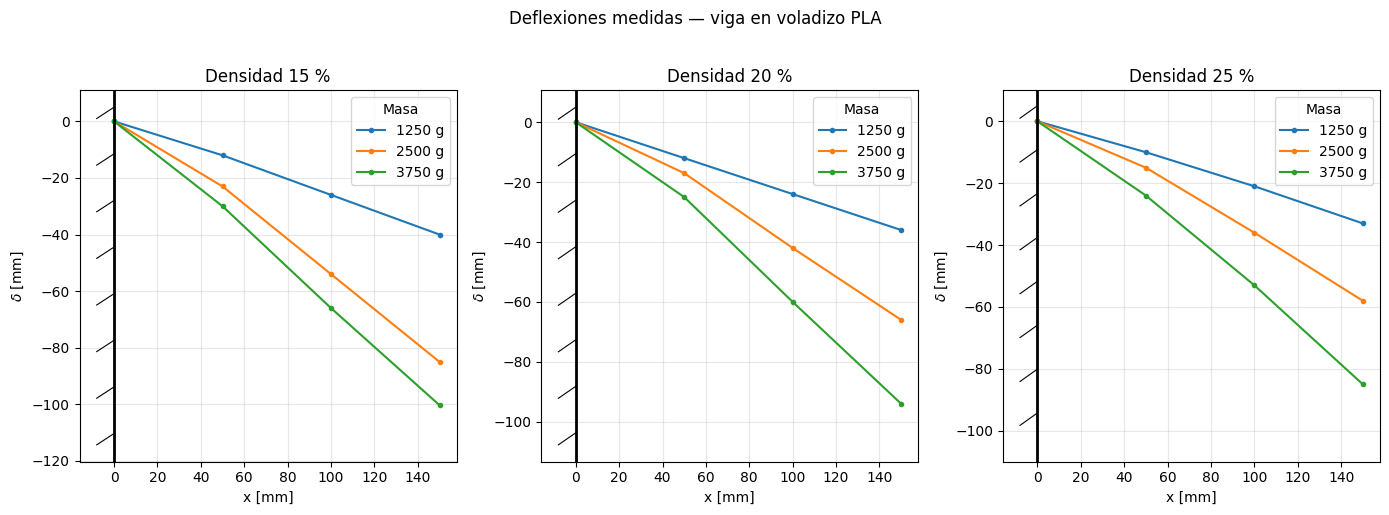

In [8]:
# ── Posiciones de medición (mm) ──────────────────────────────────────────────
locs_plot = np.array([0.0, 50.0, 100.0, 150.0])   # incluye x=0 para graficar

# ── Masas y cargas ───────────────────────────────────────────────────────────
masas_g = np.array([1250.0, 2500.0, 3750.0])       # gramos
P_N     = masas_g * 9.81e-3                        # Newtons

# ── Deflexiones medidas (mm) ─────────────────────────────────────────────────
# Fila i = masa i  |  columnas: [x=0, L/3, 2L/3, L]

delta_plot_15 = np.array([        # densidad 15%
    #  L/3    2L/3     L
    [0.0, 12.00,  26.00,  40.00],  # 1250 g
    [0.0, 23.00,  54.00,  85.00],  # 2500 g
    [0.0, 30.00,  66.00,  100.3],  # 3750 g
])

delta_plot_20 = np.array([        # densidad 20%
    [0.0,  12.00,  24.00,  36.00],  # 1250 g
    [0.0, 17.00,  42.00,  66.00],  # 2500 g
    [0.0, 25.00,  60.00,  94.00],  # 3750 g
])

delta_plot_25 = np.array([        # densidad 25%
    [0.0,  10.00,  21.00,  33.00],  # 1250 g
    [0.0, 15.00,  36.00,  58.00],  # 2500 g
    [0.0, 24.00,  53.00,  85.00],  # 3750 g
])


# ── Vectores planos para el modelo (excluye x=0) ─────────────────────────────
locs  = np.tile(locs_plot[None, 1:], (3, 1)).ravel()
P_obs = np.repeat(P_N, len(locs_plot) - 1)

delta_15 = delta_plot_15[:, 1:].ravel()
delta_20 = delta_plot_20[:, 1:].ravel()
delta_25 = delta_plot_25[:, 1:].ravel()

# ── Función para graficar como viga empotrada ─────────────────────────────────
def plot_viga(ax, locs_x, deflexiones_filas, masas, titulo):
    """Grafica deflexiones con aspecto de viga empotrada (pared izquierda)."""
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for fila, m, c in zip(deflexiones_filas, masas, colores):
        ax.plot(locs_x, -fila, '.-', color=c, label=f'{int(m)} g')

    # Pared empotrada (rayas diagonales)
    ax.axvline(x=0, color='k', linewidth=2)
    for y in np.linspace(ax.get_ylim()[0] - 5, 5, 8):
        ax.plot([-8, 0], [y - 4, y], color='k', linewidth=0.8)

    ax.set_title(titulo)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('$\\delta$ [mm]')
    ax.legend(title='Masa')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_viga(axes[0], locs_plot, delta_plot_15, masas_g, 'Densidad 15 %')
plot_viga(axes[1], locs_plot, delta_plot_20, masas_g, 'Densidad 20 %')
plot_viga(axes[2], locs_plot, delta_plot_25, masas_g, 'Densidad 25 %')
plt.suptitle('Deflexiones medidas — viga en voladizo PLA', y=1.02)
plt.tight_layout()
plt.ylim(-110, 10)
plt.show()

## Modelo — Densidad 15 %
Prior: **E ~ Normal(mu=300, sigma=150) MPa**

In [9]:
with pm.Model() as model_15:
    b = pm.Uniform('b', 14.95, 15.05)   # mm
    h = pm.Uniform('h',  6.260, 6.270)   # mm
    L = pm.Uniform('L', 149.5, 150.5)   # mm

    I = b * h**3 / 12                   # mm^4

    E = pm.Normal('E', mu=525, sigma=100)

    x      = pm.Data('x',     locs)
    P      = pm.Data('P',     P_obs)
    deltas = pm.Data('delta', delta_15)

    delta_pred = pm.Deterministic('delta_pred', P * x**2 * (3*L - x) / (6 * E * I))

    sigma = pm.HalfNormal('sigma', 1.0)

    delta_like = pm.Normal('delta_like', mu=delta_pred, sigma=sigma, observed=deltas)

    trace_15 = pm.sample(1000, chains=2, cores=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [b, h, L, E, sigma]


c:\Users\enriq\AppData\Local\Programs\Python\Python311\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 56 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


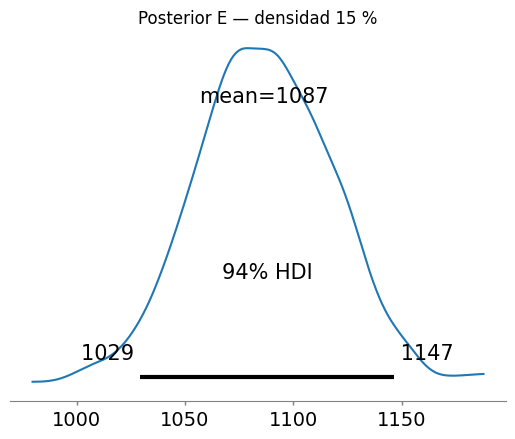

In [10]:
az.plot_posterior(trace_15, var_names='E')
plt.title('Posterior E — densidad 15 %')
plt.show()

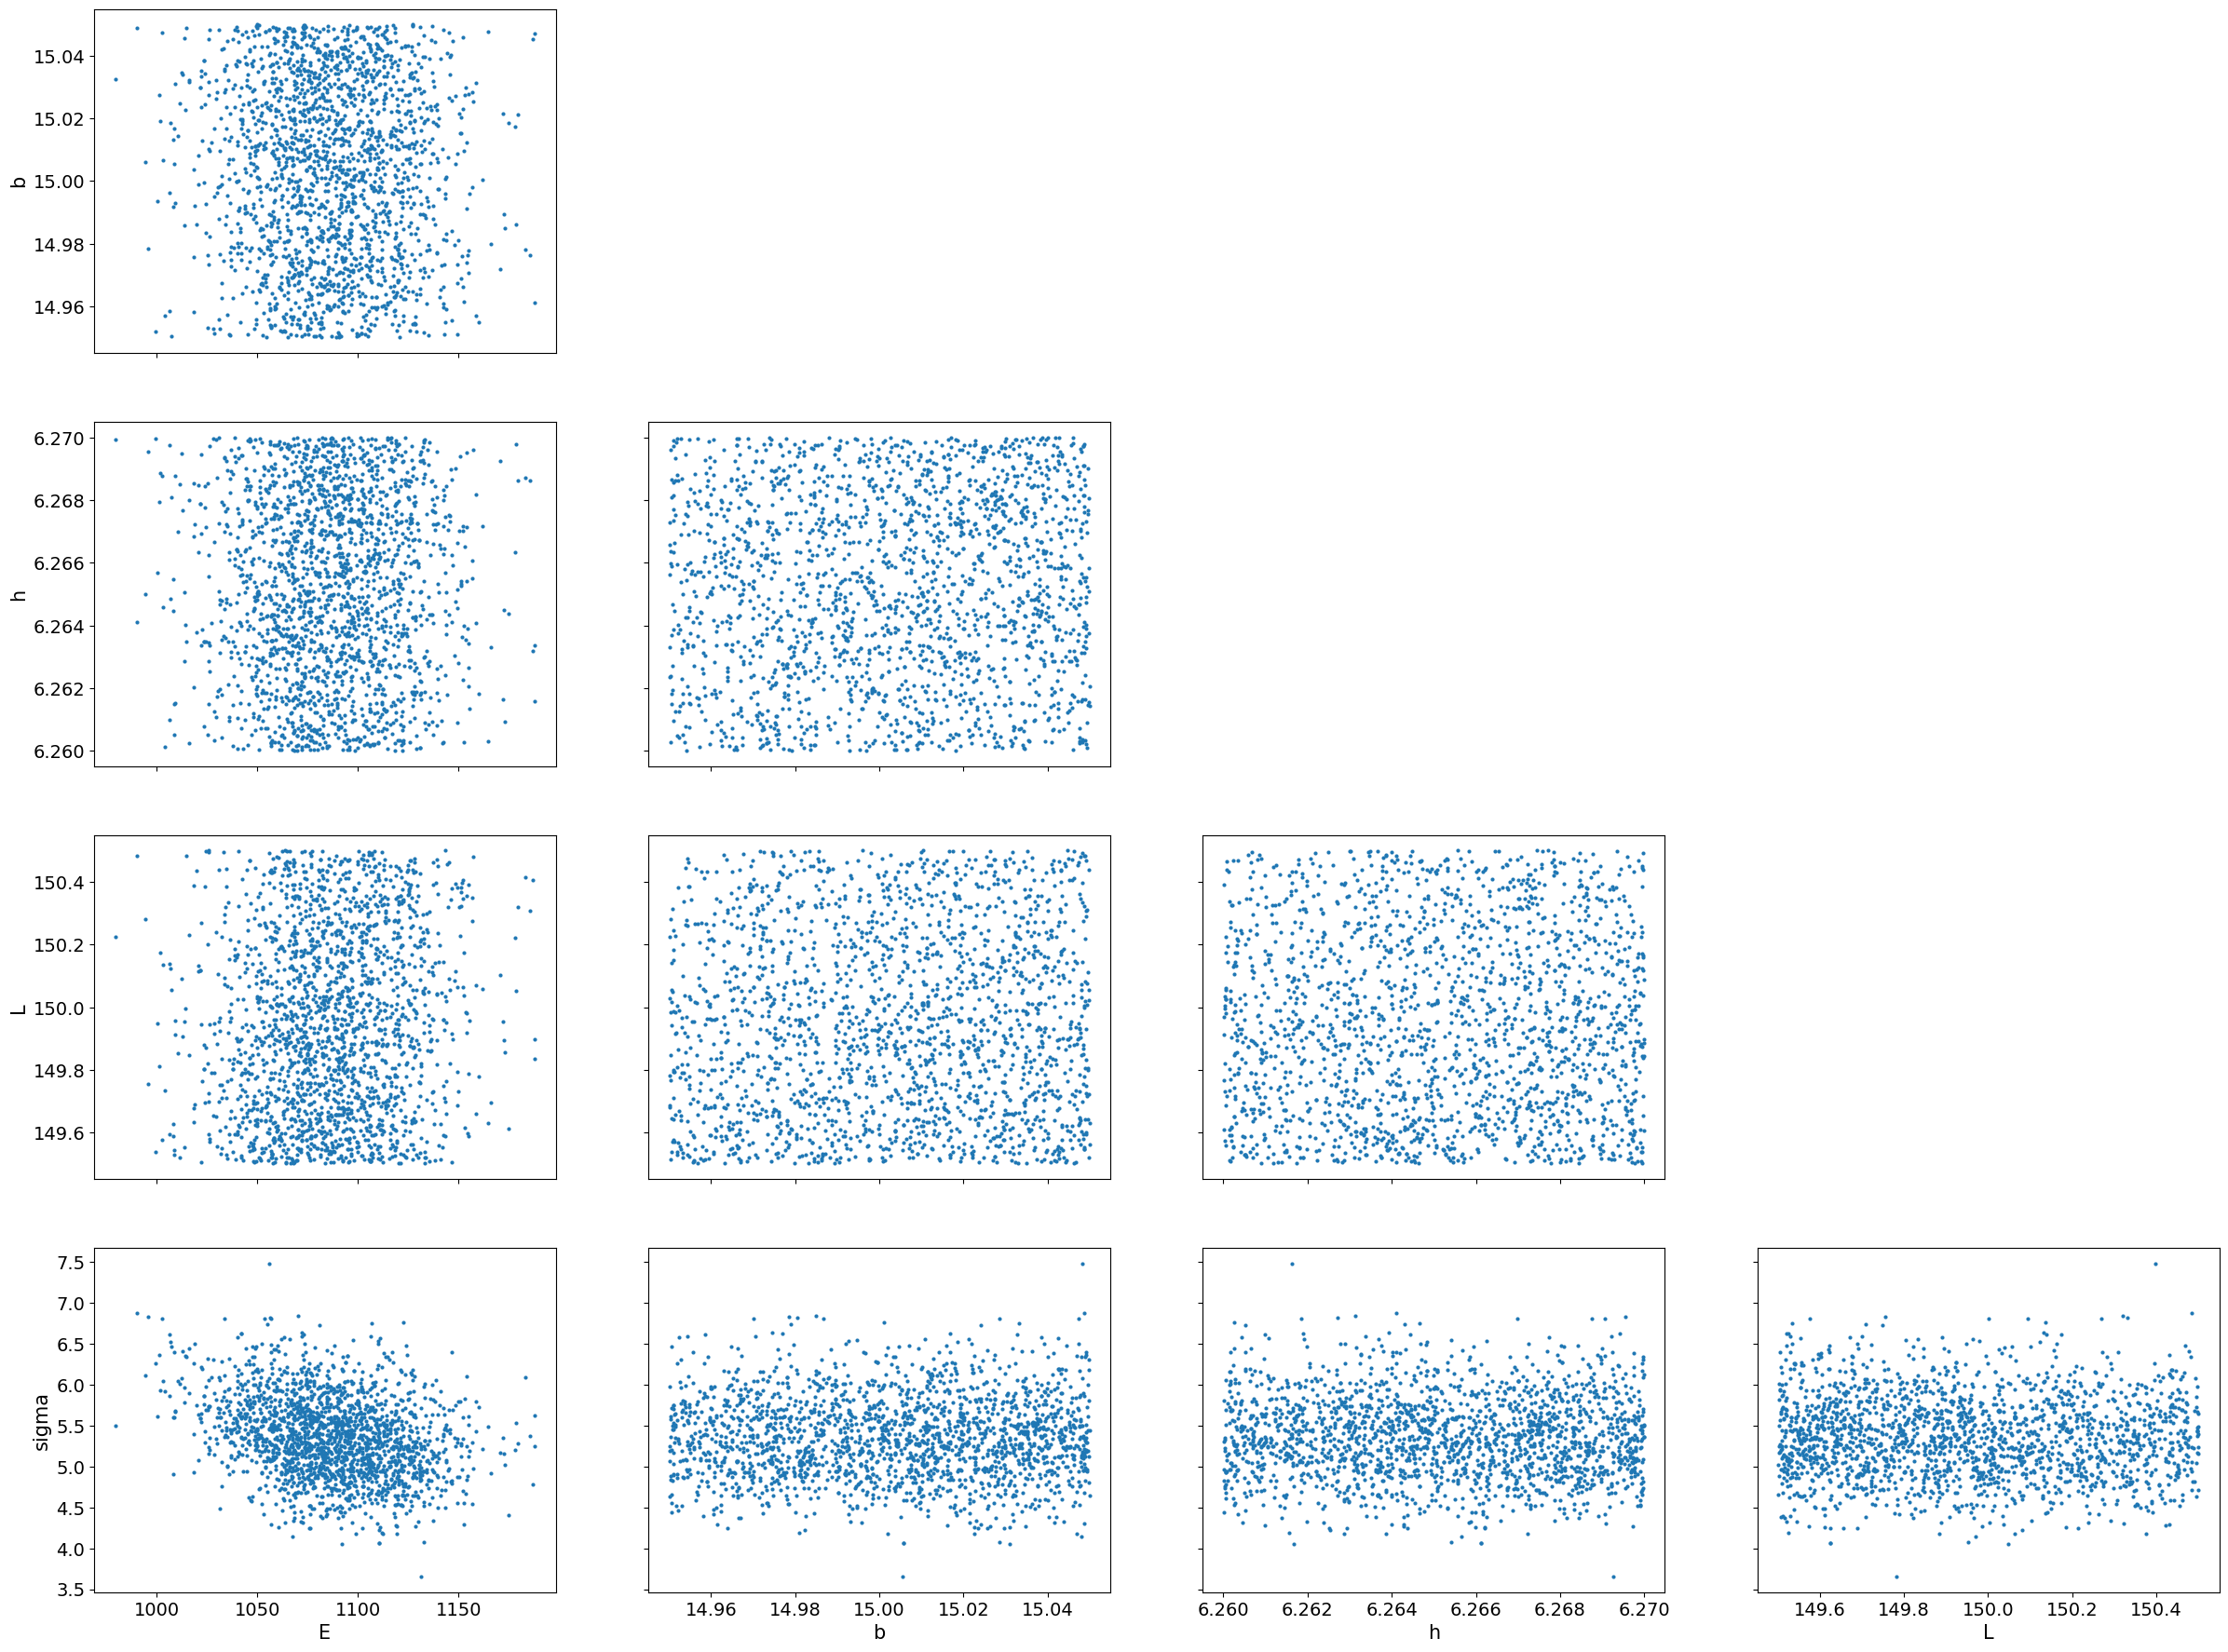

In [11]:
_ = az.plot_pair(trace_15, var_names='~delta_pred')

Sampling: [delta_like]
Sampling: [delta_like]
Sampling: [delta_like]


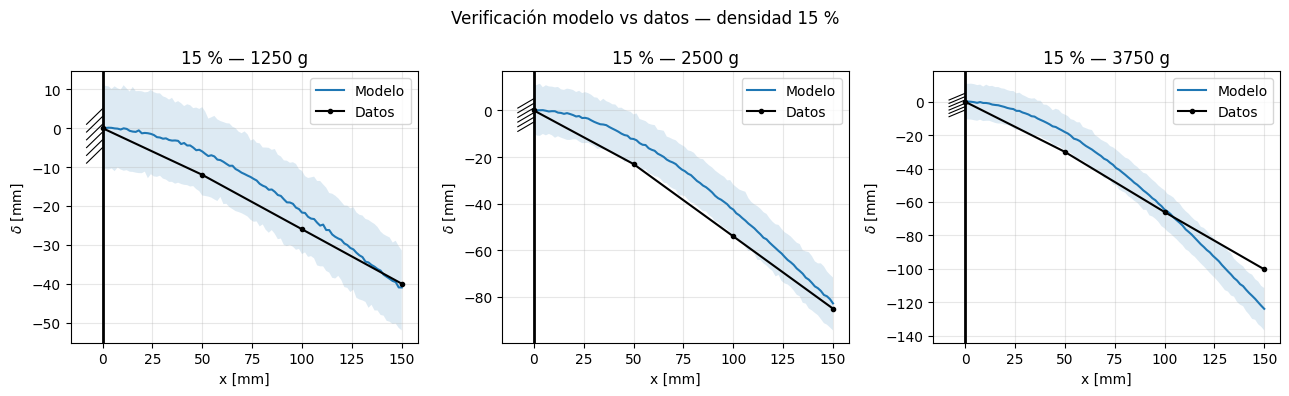

In [12]:
loc_star = np.linspace(0, 150.0, 100)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for idx, (P_i, fila, m) in enumerate(zip(P_N, delta_plot_15, masas_g)):
    P_star = np.full_like(loc_star, P_i)
    pm.set_data({'x': loc_star, 'P': P_star, 'delta': np.zeros_like(loc_star)}, model=model_15)
    ppc = pm.sample_posterior_predictive(trace_15, model=model_15, progressbar=False)

    lower      = np.percentile(ppc.posterior_predictive['delta_like'][0], q=2.5,  axis=0)
    upper      = np.percentile(ppc.posterior_predictive['delta_like'][0], q=97.5, axis=0)
    delta_star = np.median(ppc.posterior_predictive['delta_like'][0], axis=0)

    ax = axes[idx]
    ax.plot(loc_star, -delta_star, label='Modelo')
    ax.fill_between(loc_star, -lower, -upper, alpha=0.15)
    ax.plot(locs_plot, -fila, 'k.-', label='Datos')
    ax.axvline(x=0, color='k', linewidth=2)
    for y in np.linspace(-5, 5, 6):
        ax.plot([-8, 0], [y - 4, y], color='k', linewidth=0.8)
    ax.set_title(f'15 % — {int(m)} g')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('$\\delta$ [mm]')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Verificación modelo vs datos — densidad 15 %')
plt.tight_layout()
plt.show()

## Modelo — Densidad 20 %
Prior: **E ~ Normal(mu=380, sigma=150) MPa**

In [13]:
with pm.Model() as model_20:
    b = pm.Uniform('b', 14.95, 15.05)   # mm
    h = pm.Uniform('h',  6.260, 6.270)   # mm
    L = pm.Uniform('L', 149.5, 150.5)   # mm

    I = b * h**3 / 12

    E = pm.Normal('E', mu=800, sigma=100)

    x      = pm.Data('x',     locs)
    P      = pm.Data('P',     P_obs)
    deltas = pm.Data('delta', delta_20)

    delta_pred = pm.Deterministic('delta_pred', P * x**2 * (3*L - x) / (6 * E * I))

    sigma = pm.HalfNormal('sigma', 1.0)

    delta_like = pm.Normal('delta_like', mu=delta_pred, sigma=sigma, observed=deltas)

    trace_20 = pm.sample(1000, chains=2, cores=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [b, h, L, E, sigma]


c:\Users\enriq\AppData\Local\Programs\Python\Python311\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 47 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


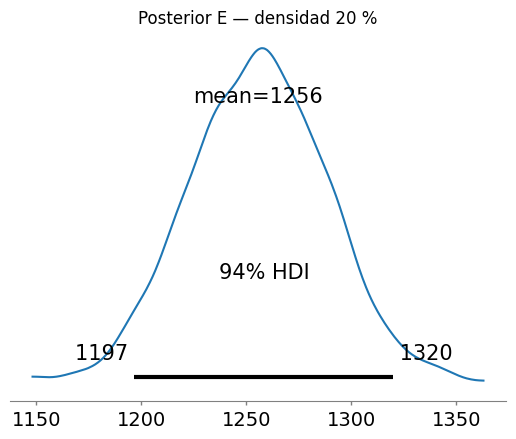

In [14]:
az.plot_posterior(trace_20, var_names='E')
plt.title('Posterior E — densidad 20 %')
plt.show()

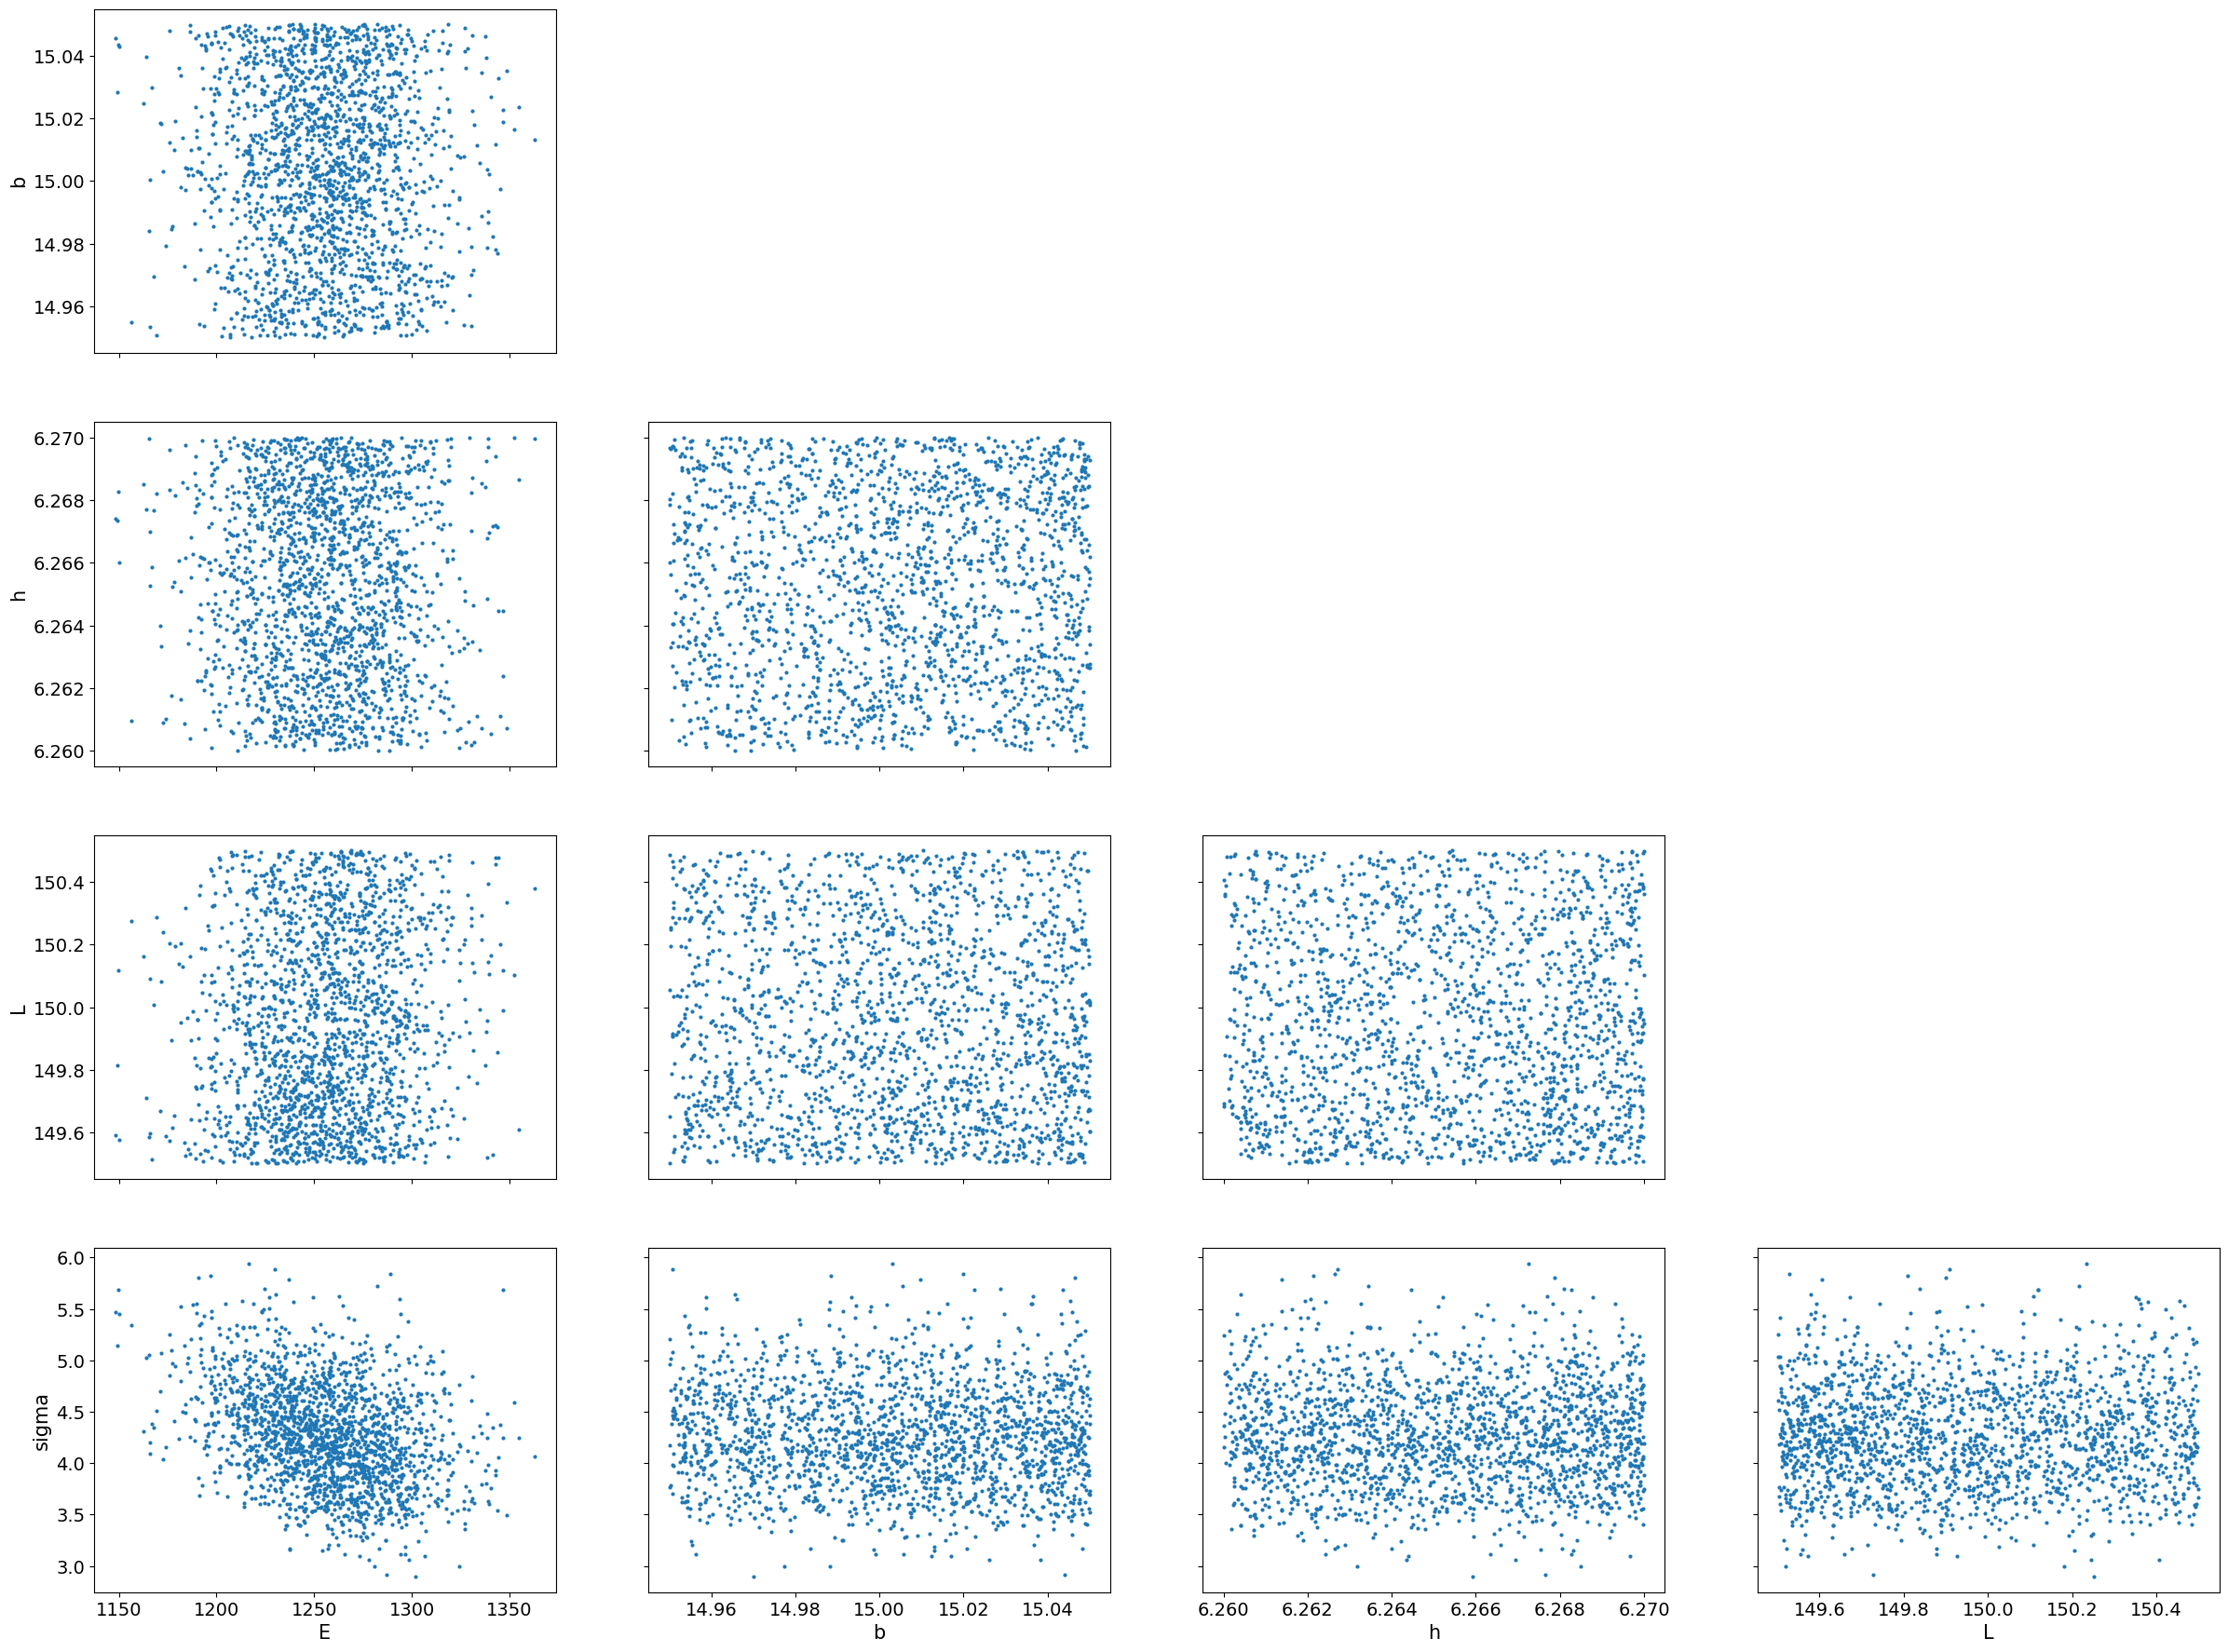

In [15]:
_ = az.plot_pair(trace_20, var_names='~delta_pred')

Sampling: [delta_like]
Sampling: [delta_like]
Sampling: [delta_like]


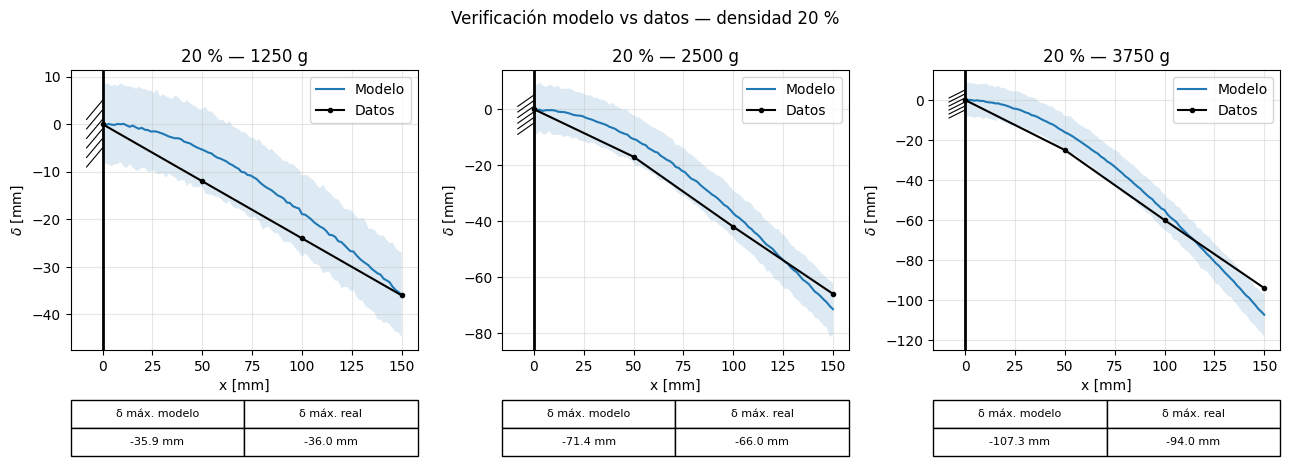

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for idx, (P_i, fila, m) in enumerate(zip(P_N, delta_plot_20, masas_g)):
    P_star = np.full_like(loc_star, P_i)
    pm.set_data({'x': loc_star, 'P': P_star, 'delta': np.zeros_like(loc_star)}, model=model_20)
    ppc = pm.sample_posterior_predictive(trace_20, model=model_20, progressbar=False)

    lower      = np.percentile(ppc.posterior_predictive['delta_like'][0], q=2.5,  axis=0)
    upper      = np.percentile(ppc.posterior_predictive['delta_like'][0], q=97.5, axis=0)
    delta_star = np.median(ppc.posterior_predictive['delta_like'][0], axis=0)

    ax = axes[idx]
    ax.plot(loc_star, -delta_star, label='Modelo')
    ax.fill_between(loc_star, -lower, -upper, alpha=0.15)
    ax.plot(locs_plot, -fila, 'k.-', label='Datos')
    ax.axvline(x=0, color='k', linewidth=2)
    for y in np.linspace(-5, 5, 6):
        ax.plot([-8, 0], [y - 4, y], color='k', linewidth=0.8)

    idx_150    = np.argmin(np.abs(loc_star - 150.0))
    val_modelo = -delta_star[idx_150]
    val_dato   = -fila[-1]

    ax.set_title(f'20 % — {int(m)} g')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('$\\delta$ [mm]')
    ax.legend()
    ax.grid(True, alpha=0.3)

    tabla = ax.table(
        cellText=[[f'{val_modelo:.1f} mm', f'{val_dato:.1f} mm']],
        colLabels=['δ máx. modelo', 'δ máx. real'],
        cellLoc='center',
        loc='bottom',
        bbox=[0, -0.38, 1, 0.2]
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(8)

plt.suptitle('Verificación modelo vs datos — densidad 20 %')
plt.tight_layout()
plt.subplots_adjust(bottom=0.30)
plt.show()

## Modelo — Densidad 25 %
Prior: **E ~ Normal(mu=460, sigma=150) MPa**

In [17]:
with pm.Model() as model_25:
    b = pm.Uniform('b', 14.95, 15.05)   # mm
    h = pm.Uniform('h',  6.260, 6.270)   # mm
    L = pm.Uniform('L', 149.5, 150.5)   # mm
    I = b * h**3 / 12

    E = pm.Normal('E', mu=950, sigma=100)

    x      = pm.Data('x',     locs)
    P      = pm.Data('P',     P_obs)
    deltas = pm.Data('delta', delta_25)

    delta_pred = pm.Deterministic('delta_pred', P * x**2 * (3*L - x) / (6 * E * I))

    sigma = pm.HalfNormal('sigma', 1.0)

    delta_like = pm.Normal('delta_like', mu=delta_pred, sigma=sigma, observed=deltas)

    trace_25 = pm.sample(1000, chains=2, cores=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [b, h, L, E, sigma]


c:\Users\enriq\AppData\Local\Programs\Python\Python311\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 47 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


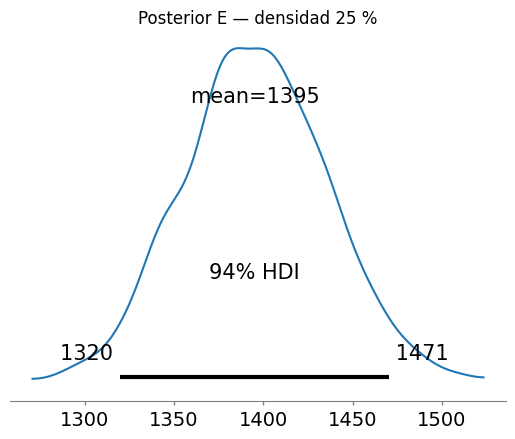

In [18]:
az.plot_posterior(trace_25, var_names='E')
plt.title('Posterior E — densidad 25 %')
plt.show()

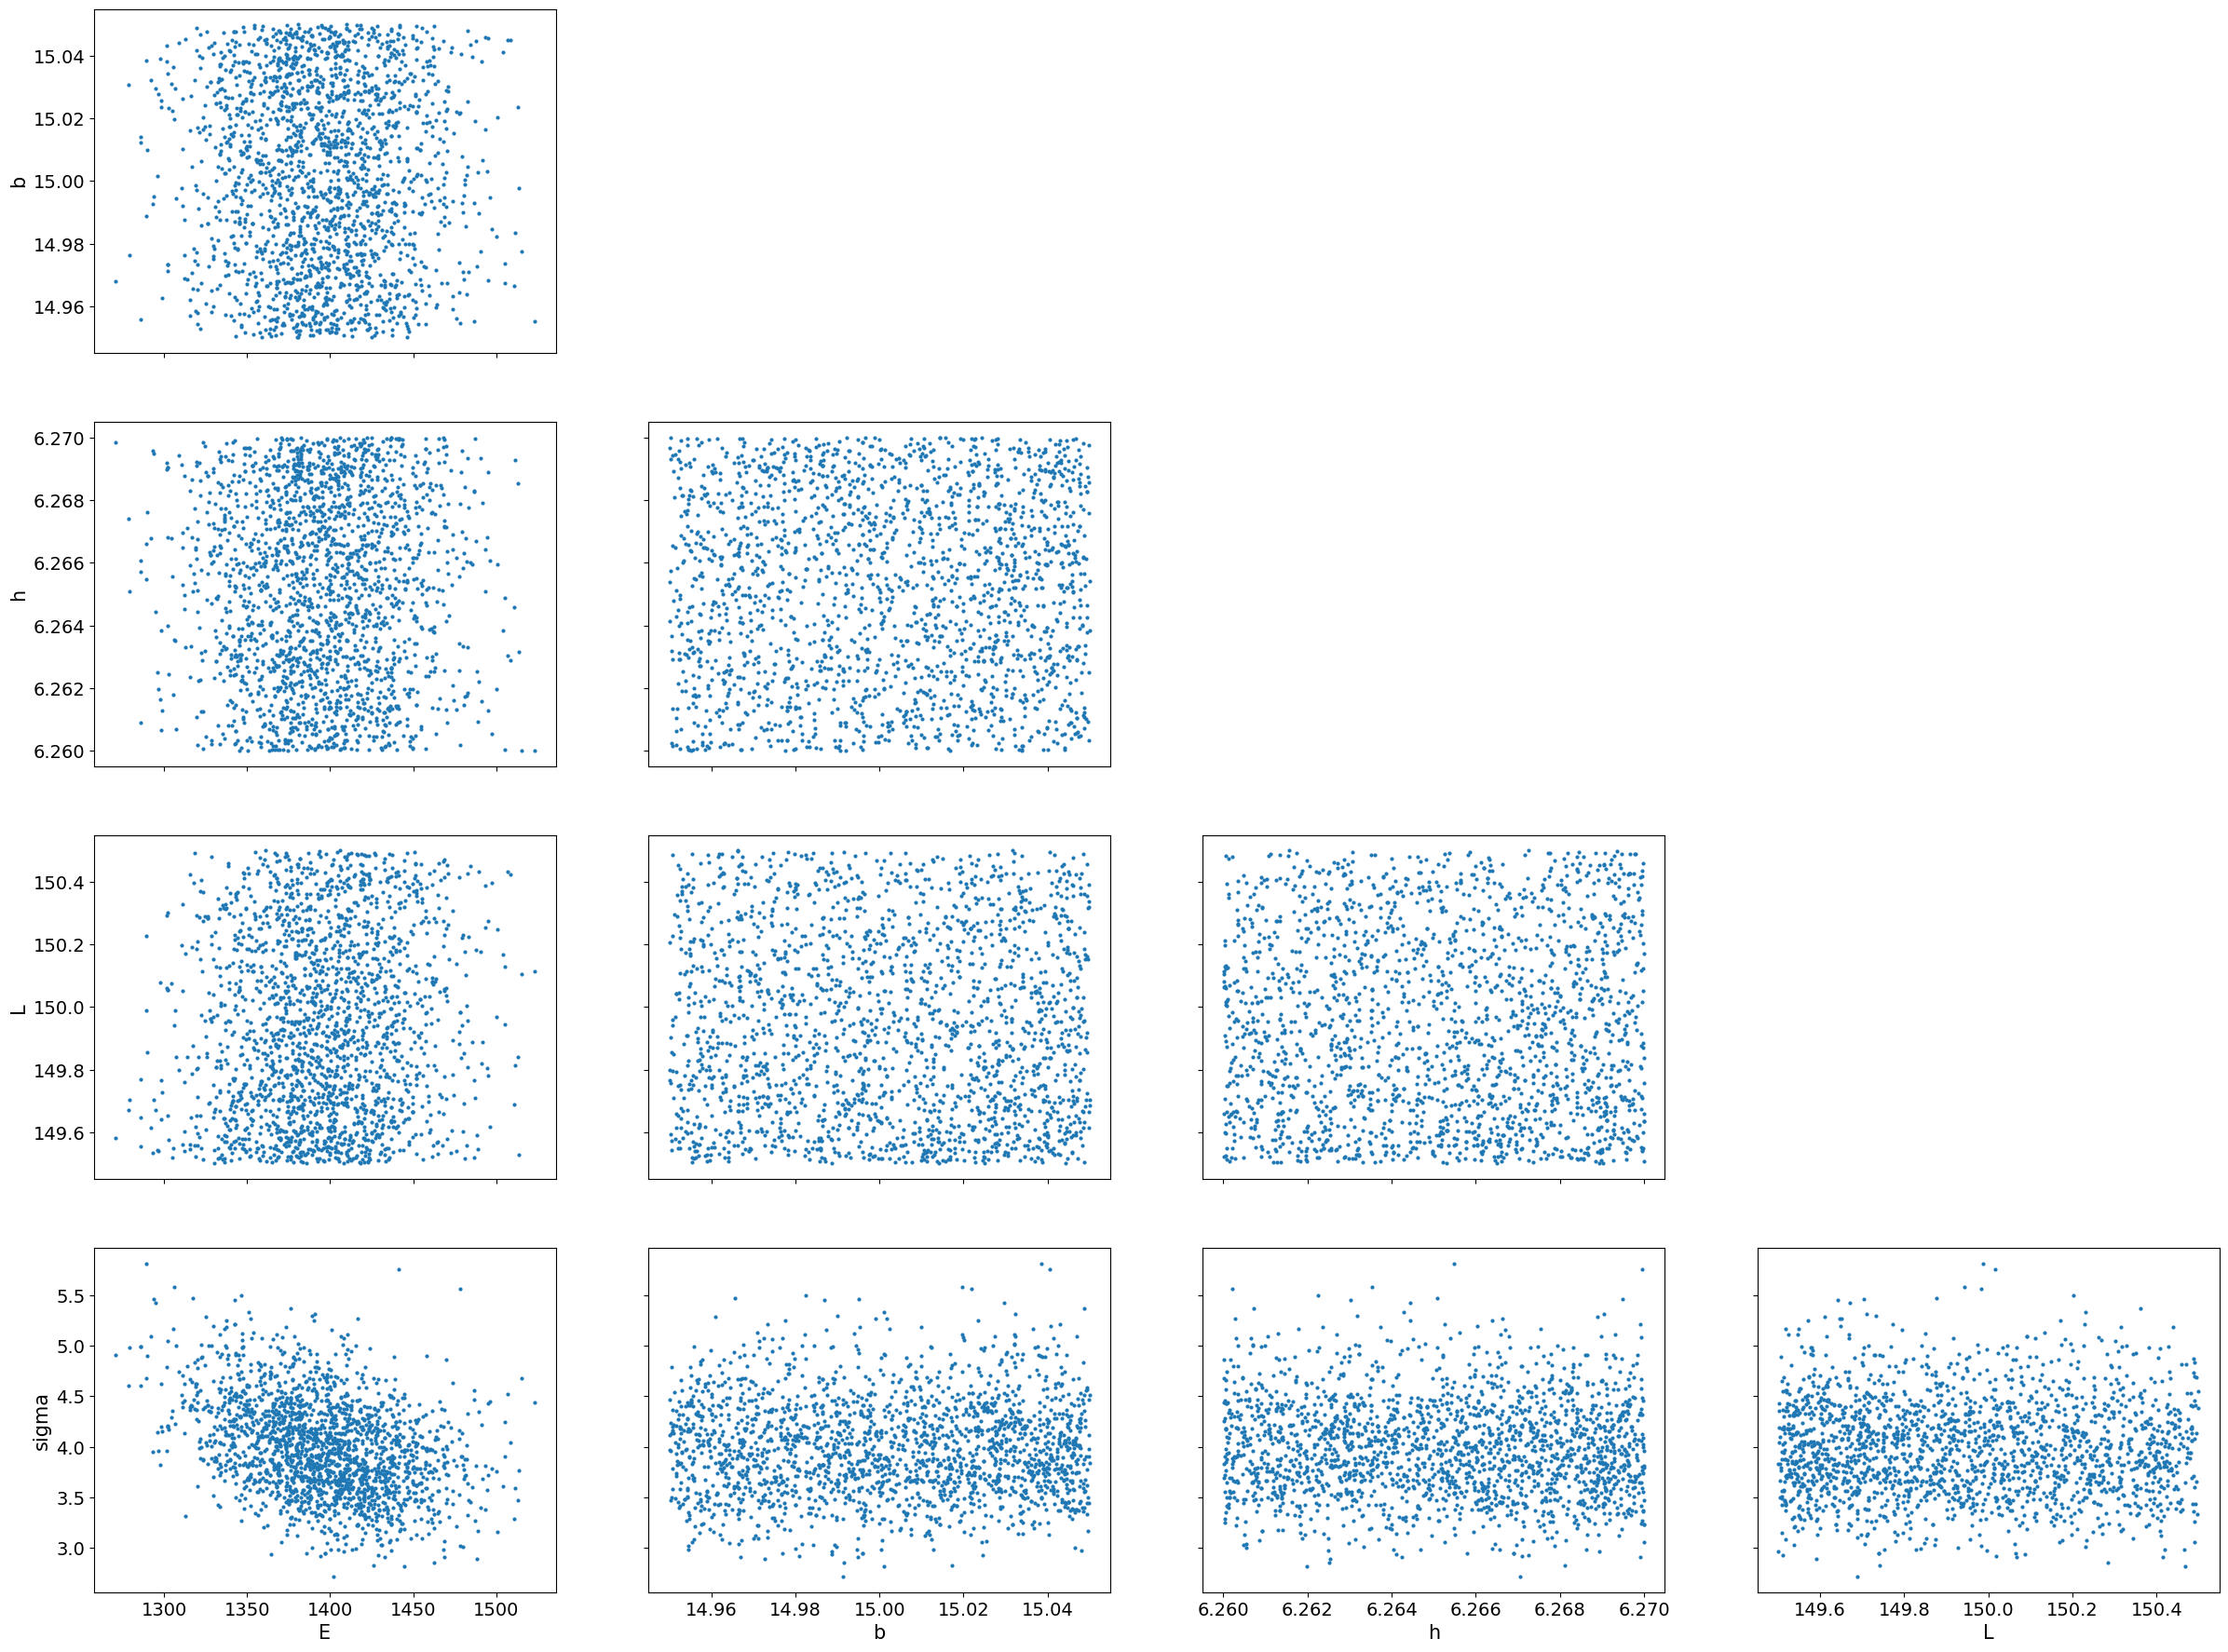

In [19]:
_ = az.plot_pair(trace_25, var_names='~delta_pred')

Sampling: [delta_like]
Sampling: [delta_like]
Sampling: [delta_like]


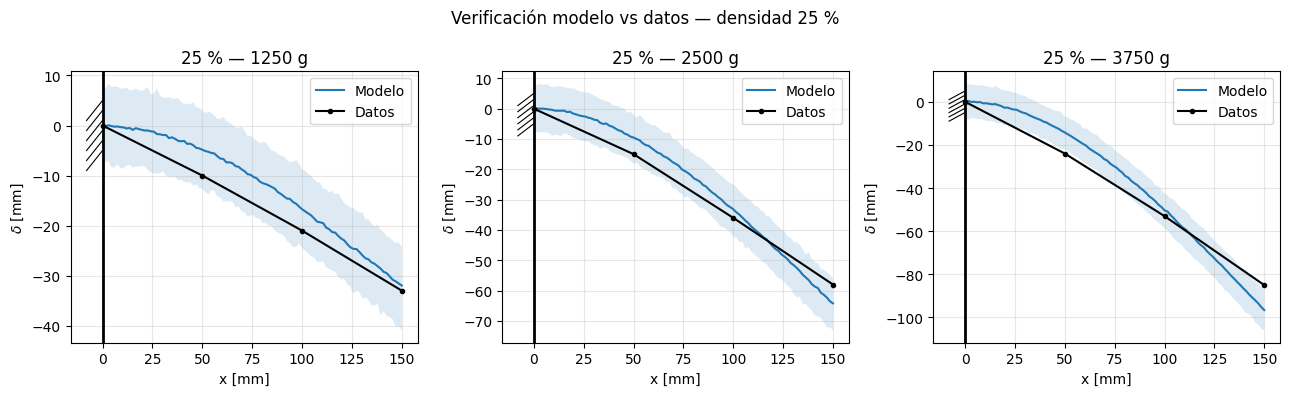

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for idx, (P_i, fila, m) in enumerate(zip(P_N, delta_plot_25, masas_g)):
    P_star = np.full_like(loc_star, P_i)
    pm.set_data({'x': loc_star, 'P': P_star, 'delta': np.zeros_like(loc_star)}, model=model_25)
    ppc = pm.sample_posterior_predictive(trace_25, model=model_25, progressbar=False)

    lower      = np.percentile(ppc.posterior_predictive['delta_like'][0], q=2.5,  axis=0)
    upper      = np.percentile(ppc.posterior_predictive['delta_like'][0], q=97.5, axis=0)
    delta_star = np.median(ppc.posterior_predictive['delta_like'][0], axis=0)

    ax = axes[idx]
    ax.plot(loc_star, -delta_star, label='Modelo')
    ax.fill_between(loc_star, -lower, -upper, alpha=0.15)
    ax.plot(locs_plot, -fila, 'k.-', label='Datos')
    ax.axvline(x=0, color='k', linewidth=2)
    for y in np.linspace(-5, 5, 6):
        ax.plot([-8, 0], [y - 4, y], color='k', linewidth=0.8)
    ax.set_title(f'25 % — {int(m)} g')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('$\\delta$ [mm]')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Verificación modelo vs datos — densidad 25 %')
plt.tight_layout()
plt.show()

## Comparación final — E por densidad

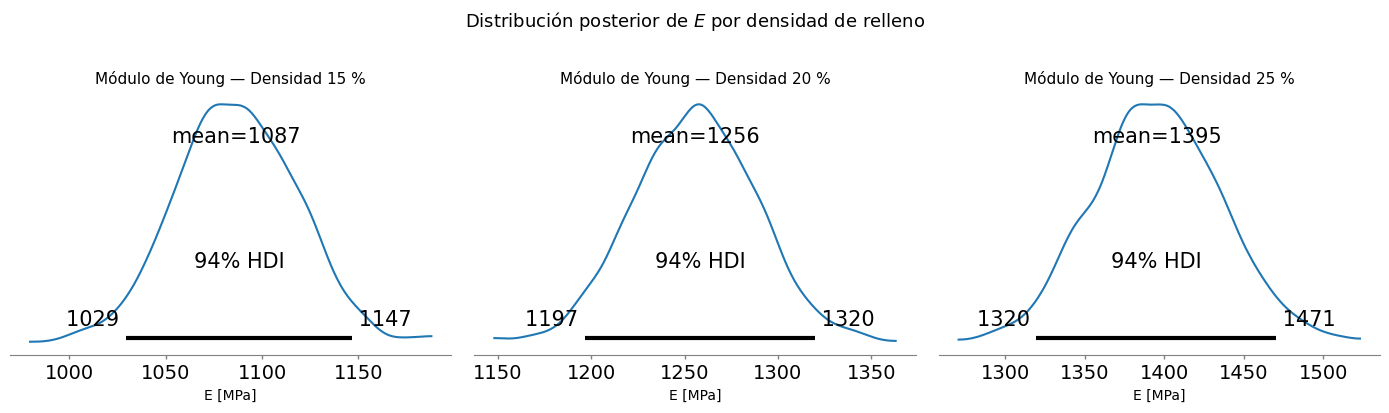

Resumen posterior E:
  15 %: 1086.6 MPa  (std 31.5)  HDI 94%: [1029.4, 1146.6]
  20 %: 1255.5 MPa  (std 33.1)  HDI 94%: [1196.7, 1320.1]
  25 %: 1395.4 MPa  (std 40.6)  HDI 94%: [1319.8, 1470.6]


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (label, tr) in zip(axes, [('15 %', trace_15), ('20 %', trace_20), ('25 %', trace_25)]):
    az.plot_posterior(tr, var_names='E', ax=ax)
    ax.set_title(f'Módulo de Young — Densidad {label}', fontsize=11)
    ax.set_xlabel('E [MPa]')

plt.suptitle('Distribución posterior de $E$ por densidad de relleno', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('posterior_E.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumen posterior E:')
for label, tr in [('15 %', trace_15), ('20 %', trace_20), ('25 %', trace_25)]:
    muestras = tr.posterior['E'].values.ravel()
    hdi = az.hdi(muestras, hdi_prob=0.94)
    print(f'  {label}: {muestras.mean():.1f} MPa  (std {muestras.std():.1f})  HDI 94%: [{hdi[0]:.1f}, {hdi[1]:.1f}]')